In [2]:
import pandas as pd
df = pd.read_csv('../data/FinalFeatureDataset04.csv')
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment,estimated_annual_spend,purchase_value_index,engagement_score,discount_dependency,customer_value_score
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional,1457.166781,54.610162,63.173486,0.117256,99.241287
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional,6870.632088,435.465225,292.663757,0.261647,1818.742563
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional,3199.126755,194.797008,421.069457,0.284785,723.313990
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value,8297.428299,585.951173,632.696615,0.104832,3840.310600
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional,9991.977507,478.096258,67.586178,0.409204,1122.755920


In [ ]:
import pickle

with open("../data/processed_variables.pkl", "rb") as f:
    data = pickle.load(f)

df = data["df"]
features = data["features"]
categorical_columns = data["categorical_columns"]
df_encoded = data["df_encoded"]
x=data["x"]
x_scaled = data["x_scaled"]
x_scaled_df = data["x_scaled_df"]
scaler = data["scaler"]

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(x_scaled)

In [5]:
df["Cluster"] = clusters

In [6]:
df["Cluster"].value_counts()

Cluster
0    23336
1    11152
3     9474
2     6038
Name: count, dtype: int64

In [7]:
# FIND OPTIMAL NUMBER OF CLUSTERS
inertia =[]
for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(x_scaled)
    inertia.append(model.inertia_)



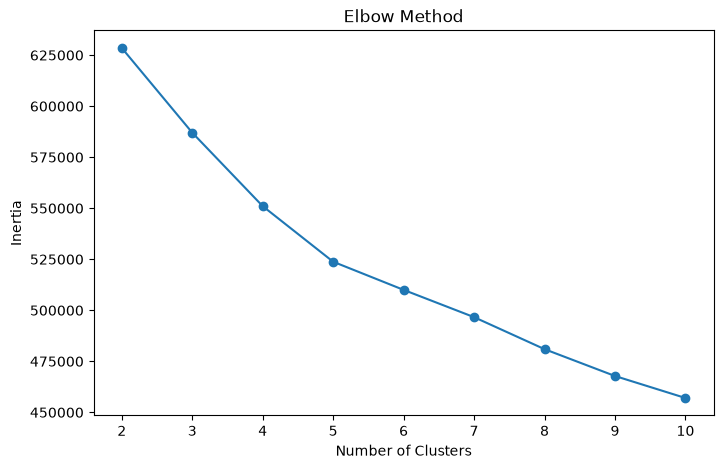

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [9]:
# SILHOUETTE SCORE
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    silhouette_scores.append(score)

    print(f"K={k}: {score:.4f}")


K=2: 0.1085
K=3: 0.1133
K=4: 0.1177
K=5: 0.1040
K=6: 0.1008
K=7: 0.1081
K=8: 0.1090
K=9: 0.1058
K=10: 0.1031


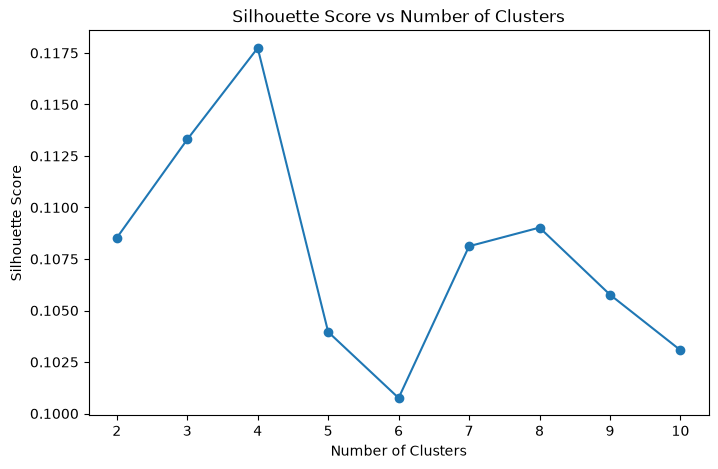

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Number of Clusters")

plt.show()

In [11]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(x_scaled)

In [12]:
import joblib

joblib.dump(final_kmeans, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [13]:
df["Cluster"] = clusters

In [14]:
df["Cluster"].value_counts()

Cluster
0    23336
1    11152
3     9474
2     6038
Name: count, dtype: int64

In [16]:
df.to_csv('../data/kmean_cluster_data05.csv',index=False)

In [17]:
import pickle

with open("../data/processed_variables.pkl", "wb") as f:
    pickle.dump({
        "df": df,
        "features": features,
        "categorical_columns":categorical_columns,
        "df_encoded":df_encoded,
        "x":x,
        "x_scaled":x_scaled,
        "x_scaled_df":x_scaled_df,
        "scaler":scaler,
        "final_kmeans":final_kmeans

    }, f)